In [ ]:
from helpers.benchmark import load_records_from_directory
from helpers.benchmark import filter_full_lifecycle, trim_on_benchmark


LOG_DIR = "/Users/jonasheisterberg/Workspace/Uni/Master/thesis/ClassiFaaS-Benchmark/results/2026-02-23_15-45/aws/us-east-1"
BENCHMARK_TYPE = "matmul"
df_raw = load_records_from_directory(LOG_DIR)
print(len(df_raw))


trimmed_df =  trim_on_benchmark(df_raw, group_on_timestamp=False, benchmark=BENCHMARK_TYPE)
print(len(trimmed_df))


2500
2473


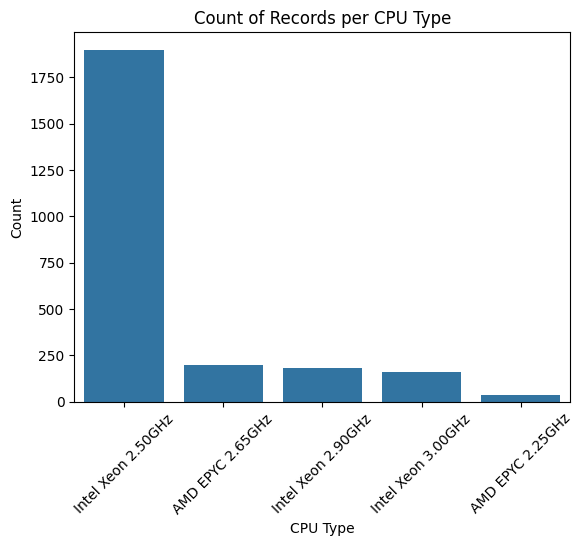

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# count the number of records per cpu_type
cpu_type_counts = trimmed_df['cpu_type'].value_counts()
sns.barplot(x=cpu_type_counts.index, y=cpu_type_counts.values)
plt.xlabel('CPU Type')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.title('Count of Records per CPU Type')
plt.show()

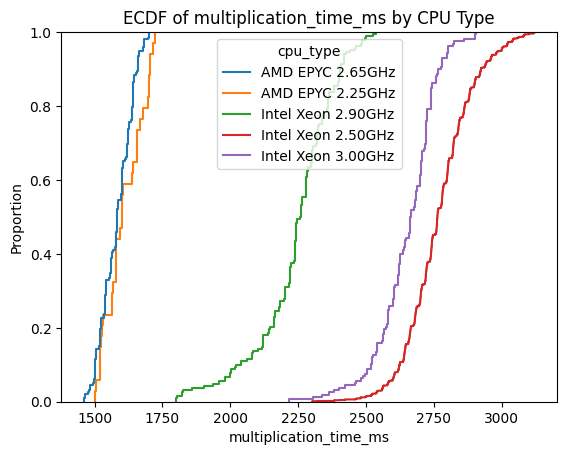

In [18]:
from helpers.benchmark import metric_for_benchmark


metric = metric_for_benchmark("matmul")

sns.ecdfplot(data=trimmed_df, x=metric, hue="cpu_type")
plt.xlabel(metric)
plt.title(f'ECDF of {metric} by CPU Type')
plt.show()
